# Parcial: Construcción e implementación de , Random Forest 

En este parcial podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de  Random Forest. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este parcial se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#librerias
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [3]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,0,0,0,1,0,0,0
11,13995,2014,39972,0,0,0,0,1,0,0
167,17941,2016,18989,0,0,0,0,0,1,0
225,12493,2014,51330,0,0,0,1,0,0,0
270,7994,2007,116065,0,1,0,0,0,0,0


In [4]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [5]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 0 - exploracion y analisis de datos 
Los estudiantes deben analizar cuidadosamente los datos del conjunto dataTrain_carListings, identificando posibles valores nulos o inconsistencias. En caso de encontrar datos faltantes, deberán aplicar técnicas de imputación adecuadas para completar la información de manera coherente. Posteriormente, se espera que realicen una exploración visual mediante gráficos que permitan comprender la distribución y las relaciones entre las variables principales.

              Price          Year        Mileage
count  10495.000000  10495.000000   10495.000000
mean   14538.403716   2013.553883   52509.430395
std     3922.420961      3.116585   36791.736601
min     5002.000000   1998.000000       5.000000
25%    11999.000000   2012.000000   26461.000000
50%    15000.000000   2014.000000   41680.000000
75%    16999.000000   2016.000000   71355.500000
max    32444.000000   2018.000000  232658.000000


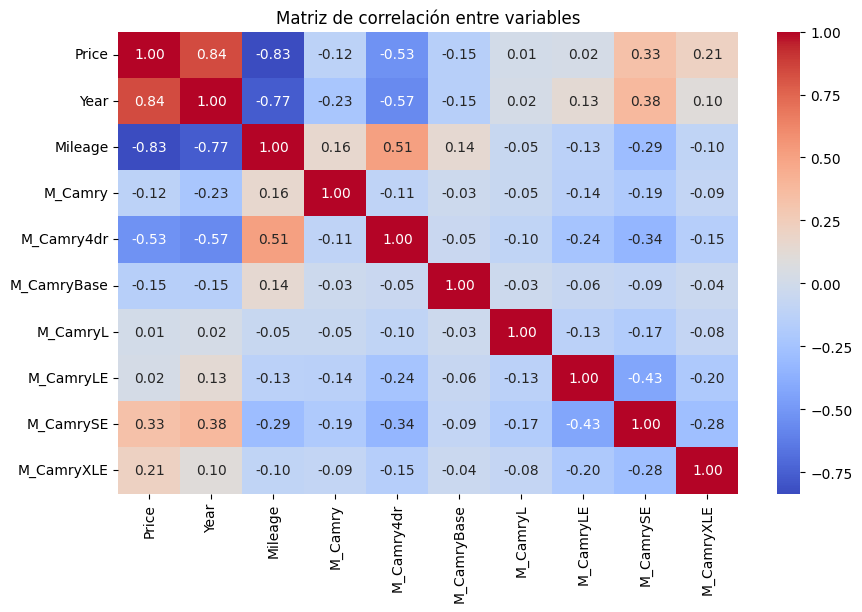

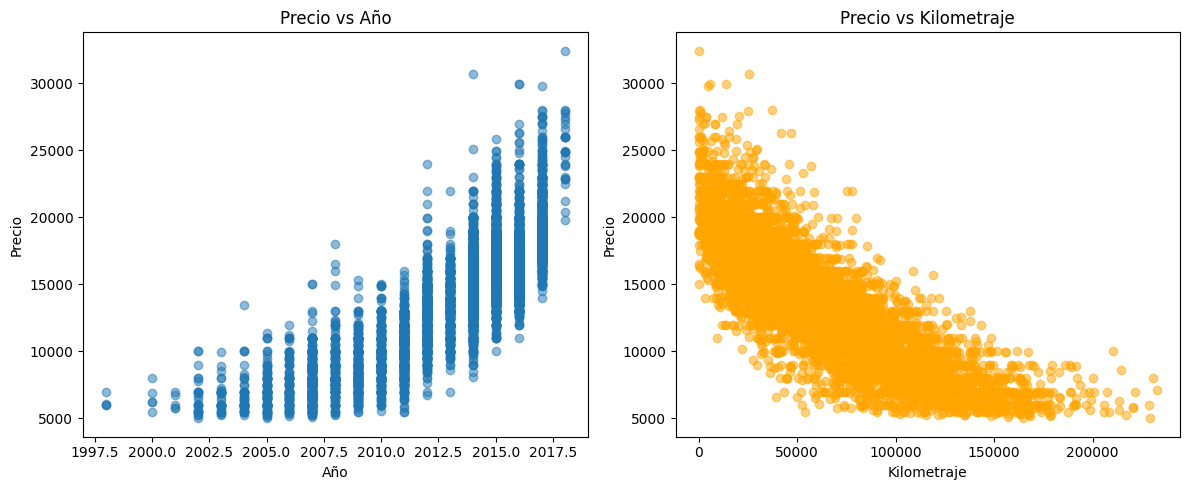

Variables seleccionadas por correlación:
 ['Year', 'Mileage', 'M_Camry4dr', 'M_CamrySE', 'M_CamryXLE']


In [15]:
# celda 0 - exploracion y analisis de datos
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# Cargar datos
url = 'https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip'
data = pd.read_csv(url)

# Filtrar por modelo Camry y codificar variables categóricas
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data.drop(['Model'], axis=1, inplace=True)

# Eliminar nulos si los hubiera
data.dropna(inplace=True)

data.head()


# Estadísticas descriptivas
print(data.describe())

# Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación entre variables')
plt.show()

# Visualización de relaciones clave
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(data['Year'], data['Price'], alpha=0.5)
axs[0].set_title('Precio vs Año')
axs[0].set_xlabel('Año')
axs[0].set_ylabel('Precio')

axs[1].scatter(data['Mileage'], data['Price'], alpha=0.5, color='orange')
axs[1].set_title('Precio vs Kilometraje')
axs[1].set_xlabel('Kilometraje')
axs[1].set_ylabel('Precio')

plt.tight_layout()
plt.show()


# Selección de variables con correlación significativa con Price
correlation_matrix = data.corr()
cor_target = correlation_matrix['Price'].abs()
selected_features = cor_target[cor_target > 0.2].index.drop('Price')

print("Variables seleccionadas por correlación:\n", selected_features.tolist())

# Definir X e y
X = data[selected_features]
y = data['Price']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)




### Punto 1 - Random forest con librería

En la celda 1, usando la librería sklearn entrenen un modelo de Randon Forest para regresion  y comenten sobre el desempeño del modelo.

In [16]:
# Celda 1
# Modelo base
rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

# Evaluación
mse = mean_squared_error(y_test, y_pred_base)
r2 = r2_score(y_test, y_pred_base)
mae = mean_absolute_error(y_test, y_pred_base)
mape = np.mean(np.abs((y_test - y_pred_base) / y_test)) * 100

print("Desempeño del modelo RF base:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f} %")


Desempeño del modelo RF base:
Mean Squared Error: 3406693.65
R^2 Score: 0.777
MAE: 1372.93
MAPE: 9.96 %


### Punto 2 - Calibración de parámetros Random forest

En la celda 2, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresion, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

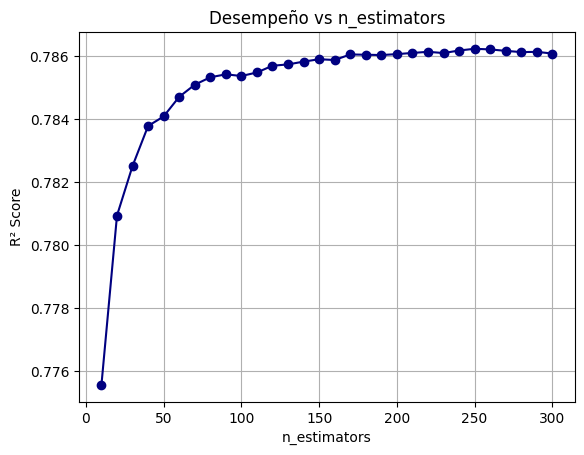

In [18]:
# Celda 2

# Calibración visual de n_estimators
estimator_range = range(10, 310, 10)
r2_scores = []

for estimator in estimator_range:
    reg = RandomForestRegressor(n_estimators=estimator, random_state=42, n_jobs=-1)
    score = cross_val_score(reg, X, y, cv=5, scoring='r2').mean()
    r2_scores.append(score)

plt.plot(estimator_range, r2_scores, marker='o', color='navy')
plt.xlabel('n_estimators')
plt.ylabel('R² Score')
plt.title('Desempeño vs n_estimators')
plt.grid(True)
plt.show()


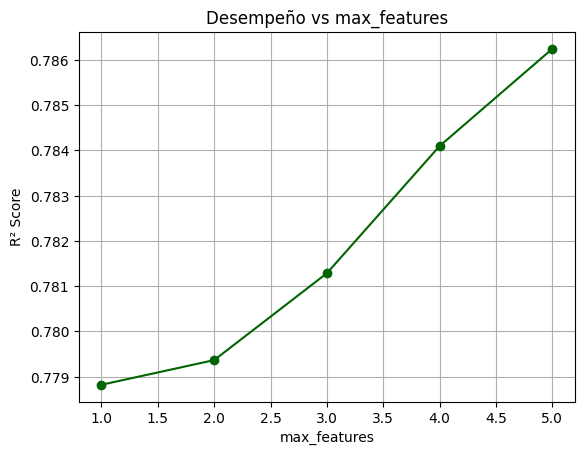

In [19]:
# Calibración visual de max_features
feature_range = range(1, len(X.columns)+1)
r2_scores = []

for feature in feature_range:
    reg = RandomForestRegressor(n_estimators=250, max_features=feature, random_state=42, n_jobs=-1)
    score = cross_val_score(reg, X, y, cv=5, scoring='r2').mean()
    r2_scores.append(score)

plt.plot(feature_range, r2_scores, marker='o', color='darkgreen')
plt.xlabel('max_features')
plt.ylabel('R² Score')
plt.title('Desempeño vs max_features')
plt.grid(True)
plt.show()



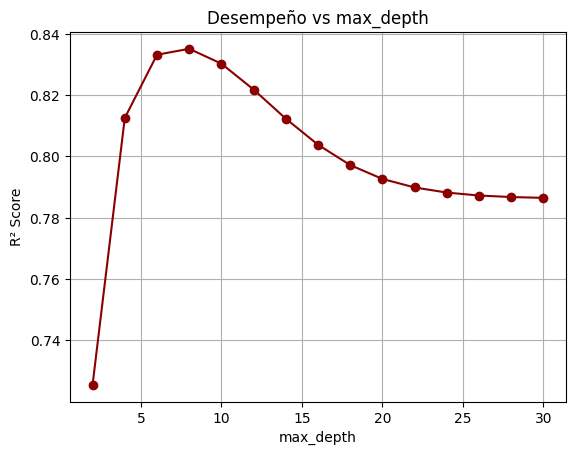

In [21]:
# Calibración visual de max_depth
depth_range = range(2, 31, 2)
r2_scores = []

for depth in depth_range:
    reg = RandomForestRegressor(n_estimators=250, max_depth=depth, random_state=42)
    score = cross_val_score(reg, X, y, cv=5, scoring='r2').mean()
    r2_scores.append(score)

plt.plot(depth_range, r2_scores, marker='o', color='darkred')
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Desempeño vs max_depth')
plt.grid(True)
plt.show()


In [22]:
# Calibración con RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'max_features': ['auto', 'sqrt'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=5, verbose=2, n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
mape_best = np.mean(np.abs((y_test - y_pred_best) / y_test)) * 100

print("Mejores hiperparámetros:", random_search.best_params_)
print("Desempeño del modelo RF calibrado:")
print(f"Mean Squared Error: {mse_best:.2f}")
print(f"R^2 Score: {r2_best:.3f}")
print(f"MAE: {mae_best:.2f}")
print(f"MAPE: {mape_best:.2f} %")




Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.1s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=2, n_estimator

In [23]:
# Validación cruzada del modelo final
scores = cross_val_score(best_rf, X, y, cv=10, scoring='r2')
print("R² promedio:", scores.mean())
print("Desviación estándar:", scores.std())


R² promedio: 0.8357111938776539
Desviación estándar: 0.013036526660694549


### Punto 3 - análisis de resultados, gracias y conclusiones
En la celda 3

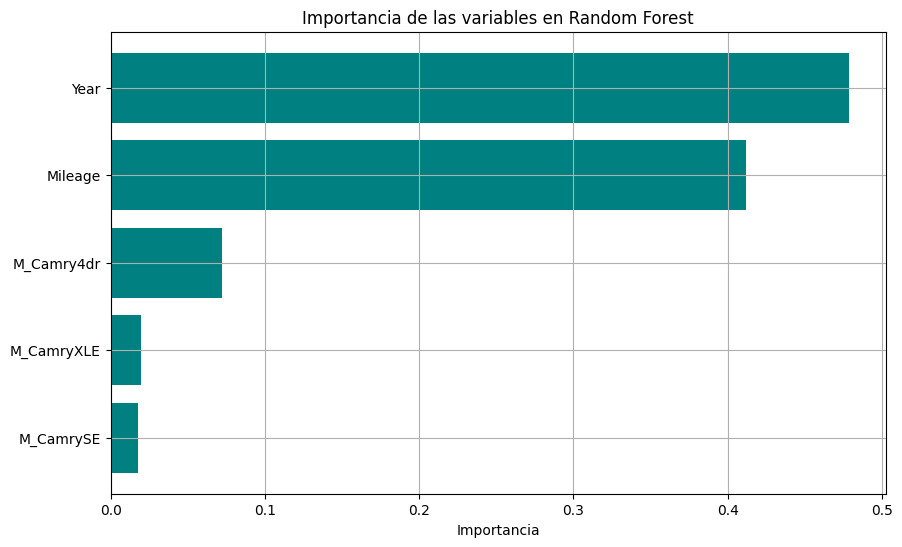

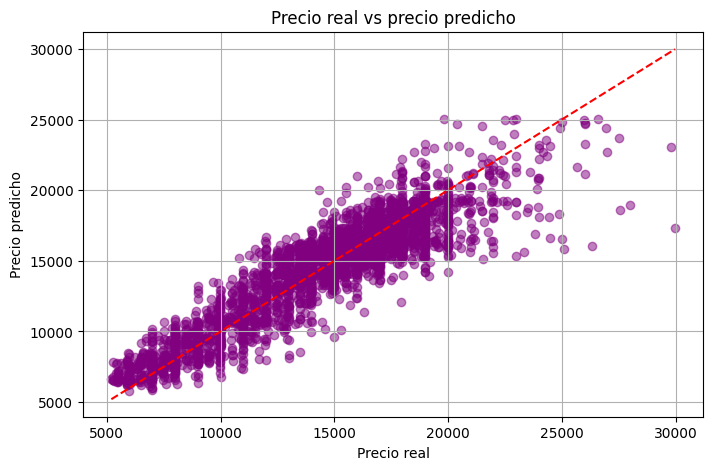

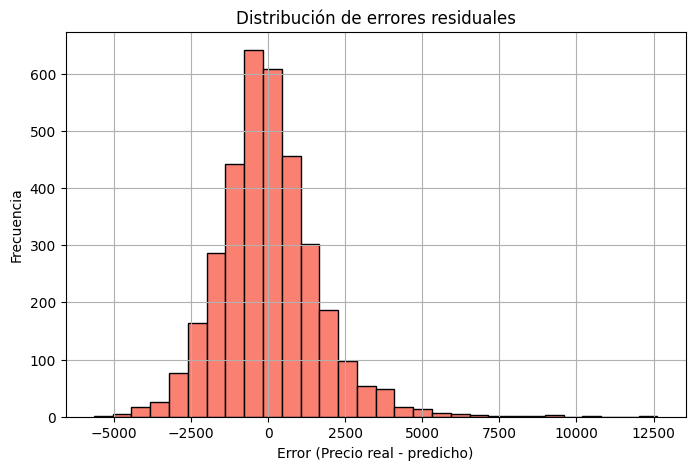

In [25]:
#celda 3
# Importancia de las variables
importances = best_rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.title('Importancia de las variables en Random Forest')
plt.xlabel('Importancia')
plt.grid(True)
plt.show()


# Precio real vs predicho
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Precio real vs precio predicho')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.grid(True)
plt.show()

# Errores residuales
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='salmon', edgecolor='black')
plt.title('Distribución de errores residuales')
plt.xlabel('Error (Precio real - predicho)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()



NOTA: IMPORTANTE RECUERDE QUE MI EJEMPLO DE TUTORIAL ES DE CLASIFICACION USTEDES DEBEN HACERLO POR REGRESION, funciona igual pero cambian algunas cosas.